In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import unicodedata
import re
import pickle

In [20]:
from pysr import PySRRegressor

# Verifique se o PySR está instalado corretamente
try:
    from pysr import PySRRegressor
    print("PySR importado com sucesso!")
except ImportError as e:
    print(f"Erro ao importar PySR: {e}")
    print("Tente reinstalar com: pip install 'pysr==0.15.0'")

PySR importado com sucesso!


In [21]:
df = pd.read_excel("./dados para machine learning_r02.xlsx", 
                   "Dataset com TS variável MC2020", decimal=',') 
df = df.drop(['Autor', 'predict'], axis=1)

def limpar_nome_coluna(nome):
    nome = unicodedata.normalize('NFKD', nome).encode('ASCII', 'ignore').decode('ASCII')
    nome = re.sub(r'[^a-zA-Z0-9_]', '_', nome)
    nome = re.sub(r'_+', '_', nome)
    nome = nome.strip('_')
    return nome

df.columns = [limpar_nome_coluna(col) for col in df.columns]

df['error_modelo_4'] = df['w_mm'] - df['modelo_4']
df['error_modelo_5'] = df['w_mm'] - df['modelo_5']

X = df.drop(["w_mm", "modelo_3", "modelo_4", "modelo_5", "erro_modelo_3", "error_modelo_4", "error_modelo_5"], axis=1)
y = df["erro_modelo_3"]
# y_prime = np.sign(y) * np.log1p(np.abs(y))
y_prime = y.copy()

In [22]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y_prime, test_size=0.2)

In [23]:
model = PySRRegressor(
                        parsimony=0.01,           # Aumentei para reduzir complexidade
                        maxsize=10,               # Reduzi o tamanho máximo
                        maxdepth=10,               # Reduzi bastante a profundidade
                        population_size=100,      # Reduzi a população
                        ncycles_per_iteration=400, # Reduzi ciclos
                        niterations=200,           # Menos iterações para teste
                        adaptive_parsimony_scaling=50,  # Aumentei para convergir mais rápido
                        deterministic=True,       # True é geralmente mais rápido
                        should_optimize_constants=True,
                        optimizer_algorithm="BFGS",
                        optimizer_nrestarts=3,    # Reduzi restartes
                        binary_operators=["+", "-", "*", "/"],  # Removi operadores complexos inicialmente
                        unary_operators=["sin", "cos", "exp"],       # REMOVA operadores unários inicialmente
                        weight_optimize=0.002,
                        verbosity=1,
                        progress=True,
                        parallelism='serial',
                        random_state=42,
                        # Early stopping para evitar tempo desperdiçado:
                        early_stop_condition=1e-8,
                     )

model.fit(X_train, y_train)

/home/wmpjrufg/Documents/ic_andre_rimes/env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.260e+05
Progress: 521 / 6200 total iterations (8.403%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.745e-03  0.000e+00  y = -7.1265e-05
3           7.977e-03  4.593e-02  y = Momento_fletor_Ms_kNm * 0.00034573
4           6.291e-03  2.375e-01  y = sin(Numero_de_barras_em_uma_camada) * -0.06204
5           5.935e-03  5.818e-02  y = sin(exp(Numero_de_barras_em_uma_camada)) * -0.064427
6           4.851e-03  2.017e-01  y = 0.0084499 / (-0.23546 - cos(Largura_da_viga_b_mm))
7           4.809e-03  8.605e-03  y = 0.0084629 / sin(-0.23531 - cos(Largura_da_viga_b_mm))
8           4.727e-03  1.732e-02  y = -0.013772 + (0.0060181 / (-0.25156 - cos(Largura_da_vi...
                                      ga_b_mm)))
9           4.711e-03  3.451e-03  y = -

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                        -7.12646e-5   
	1        0.045931              Momento_fletor_Ms_kNm * 0.00034565365   
	2        0.237490  sin(Numero_de_barras_em_uma_camada) * -0.06204017   
	3  >>>>  0.224756  0.03658423 / (Numero_de_barras_em_uma_camada +...   
	4        0.035155  0.008359875 / (-0.23587291 - cos(Largura_da_vi...   
	5        0.012275  sin(0.010473472 / (-0.28678972 - cos(Largura_d...   
	6        0.122421  (Espacamento_entre_as_barras_mm - (Tensao_na_a...   
	7        0.022839  (Espacamento_entre_as_barras_mm - (sin(sin(Num...   
	8        0.144670  Distancia_ao_centro_de_gravidade_da_armadura_m...   
	
	       loss  complexity  
	0  0.008745           1  
	1  0.007977           3  
	2  0.006291           4  
	3  0.005025           5  
	4  0.004851           6  
	5  0.004792           7  
	6  0.004240           8  
	7  0.004144           9  
	8  0.003586          10  
]

  - outputs/20251111_163120_eib7HM/hall_of_fame.csv


In [24]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# y_reconstructed = np.sign(y_prime) * (np.expm1(np.abs(y_prime)))  # expm1(x) = exp(x)-1

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"Train RMSE: {rmse_train}")
print(f"Test RMSE: {rmse_test}")
print(f"Train R2: {r2_train}")
print(f"Test R2: {r2_test}")
best_eq = model.get_best()
best_equation = best_eq['equation']
print(f"Best Equation: {best_equation}")

Train RMSE: 0.07088374362085688
Test RMSE: 0.06906444292757541
Train R2: 0.4254153404787968
Test R2: 0.5345730402919533
Best Equation: 0.03658423 / (Numero_de_barras_em_uma_camada + -3.7078977)


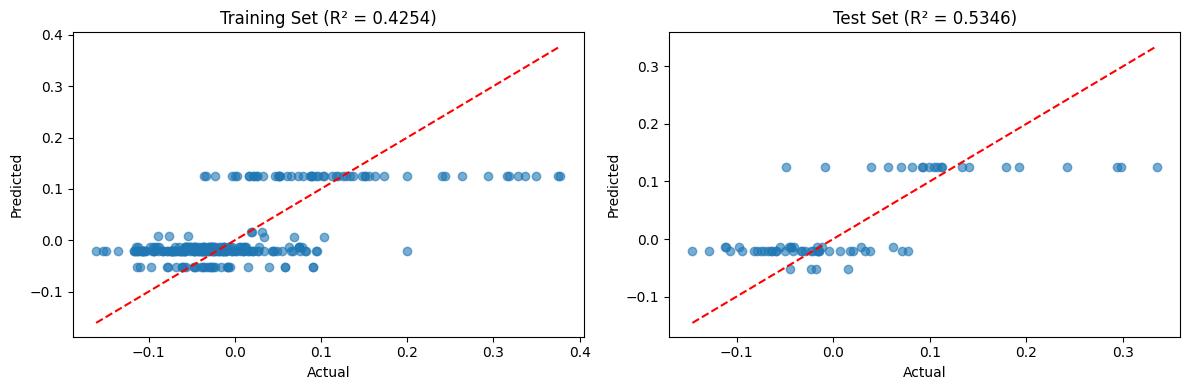

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f'Training Set (R² = {r2_train:.4f})')

ax2.scatter(y_test, y_pred_test, alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'Test Set (R² = {r2_test:.4f})')

plt.tight_layout()
plt.show()

In [26]:
best_eq = model.get_best()
print(f"Best equation: {best_eq['equation']}")
print(f"Complexity: {best_eq['complexity']} nodes")

Best equation: 0.03658423 / (Numero_de_barras_em_uma_camada + -3.7078977)
Complexity: 5 nodes


In [27]:
import sympy as sp
from IPython.display import display, Latex

equation_sympy = model.sympy()
equation_latex = sp.latex(equation_sympy)

table_latex = f"""
\\begin{{array}}{{|l|c|}}
\\hline
\\textbf{{Metric}} & \\textbf{{Value}} \\\\
\\hline
\\text{{Equation}} & {equation_latex} \\\\
\\hline
R^2 \\text{{ (Train)}} & {r2_train:.4f} \\\\
\\hline
R^2 \\text{{ (Test)}} & {r2_test:.4f} \\\\
\\hline
\\text{{RMSE (Train)}} & {rmse_train:.4f} \\\\
\\hline
\\text{{RMSE (Test)}} & {rmse_test:.4f} \\\\
\\hline
\\end{{array}}
"""

display(Latex(table_latex))

<IPython.core.display.Latex object>